Using GPU: Tesla V100-PCIE-32GB

================ Seed 42 ================

Standard BP    | test_rmse=55.7399 | test_mae=45.2700 | test_r2=0.4420 | epochs_to_target=9
Geometry-local | test_rmse=56.0080 | test_mae=44.5274 | test_r2=0.4366 | test_local=2.3604 | epochs_to_target=21

================ Seed 43 ================

Standard BP    | test_rmse=55.4175 | test_mae=44.0216 | test_r2=0.4980 | epochs_to_target=10
Geometry-local | test_rmse=54.6064 | test_mae=44.0154 | test_r2=0.5126 | test_local=2.0229 | epochs_to_target=14

================ Seed 44 ================

Standard BP    | test_rmse=55.5847 | test_mae=44.7734 | test_r2=0.3569 | epochs_to_target=16
Geometry-local | test_rmse=55.2575 | test_mae=44.1866 | test_r2=0.3645 | test_local=2.3915 | epochs_to_target=15

================ Seed 45 ================

Standard BP    | test_rmse=56.2786 | test_mae=43.3955 | test_r2=0.4102 | epochs_to_target=nan
Geometry-local | test_rmse=55.2429 | test_mae=42.9170 | test_r2=0.4317 | test_loc

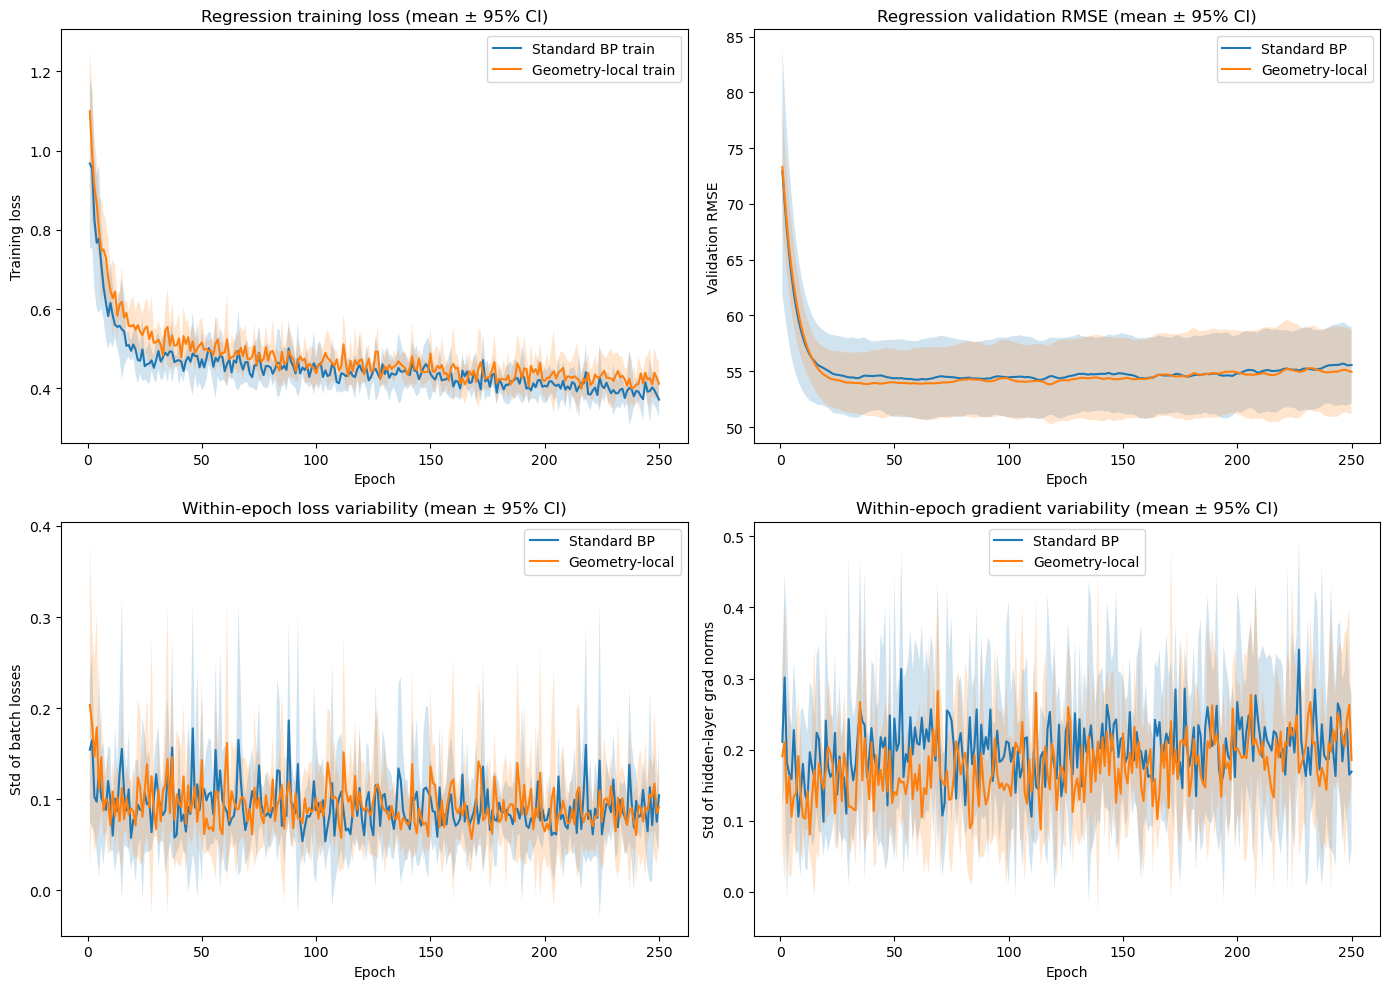

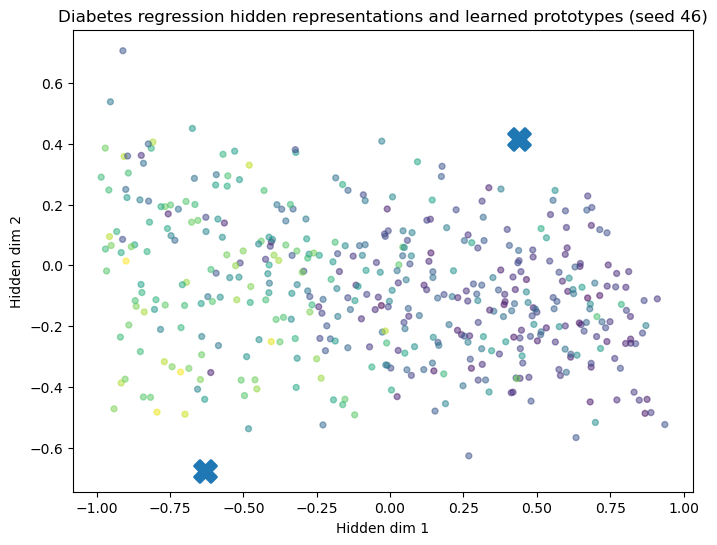

In [10]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ============================================================
# Device
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("Using GPU:", torch.cuda.get_device_name(0))
else:
    print("Using CPU")

# ============================================================
# Global settings
# ============================================================
NUM_SEEDS = 5
SEEDS = [42, 43, 44, 45, 46]

hidden_dim = 32
epochs = 250
lr = 1e-3

# Geometry-local hyperparameters
lambda_local = 0.01
num_prototypes = 2
tau = 15.0

batch_size_train = 64
batch_size_eval = 256

# Optional target threshold for val RMSE
target_rmse = 55.0

# 95% CI t-critical value for df = 4 (5 seeds)
T_CRIT_95_DF4 = 2.776

# ============================================================
# Reproducibility helper
# ============================================================
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

# ============================================================
# Data
# Diabetes dataset is built into sklearn
# We standardize X and y using training statistics only
# ============================================================
def make_diabetes_loaders(seed: int):
    set_seed(seed)

    data = load_diabetes()
    X = data.data.astype(np.float32)
    y = data.target.astype(np.float32).reshape(-1, 1)

    n = len(X)
    perm = np.random.RandomState(seed).permutation(n)

    X = X[perm]
    y = y[perm]

    n_train = int(0.6 * n)
    n_val = int(0.2 * n)

    X_train = X[:n_train]
    y_train = y[:n_train]

    X_val = X[n_train:n_train + n_val]
    y_val = y[n_train:n_train + n_val]

    X_test = X[n_train + n_val:]
    y_test = y[n_train + n_val:]

    # Standardize X from train stats
    x_mean = X_train.mean(axis=0, keepdims=True)
    x_std = X_train.std(axis=0, keepdims=True) + 1e-8

    X_train_std = (X_train - x_mean) / x_std
    X_val_std = (X_val - x_mean) / x_std
    X_test_std = (X_test - x_mean) / x_std

    # Standardize y from train stats for stable training
    y_mean = y_train.mean(axis=0, keepdims=True)
    y_std = y_train.std(axis=0, keepdims=True) + 1e-8

    y_train_std = (y_train - y_mean) / y_std
    y_val_std = (y_val - y_mean) / y_std
    y_test_std = (y_test - y_mean) / y_std

    train_loader = DataLoader(
        TensorDataset(
            torch.tensor(X_train_std, dtype=torch.float32),
            torch.tensor(y_train_std, dtype=torch.float32)
        ),
        batch_size=batch_size_train,
        shuffle=True
    )

    val_loader = DataLoader(
        TensorDataset(
            torch.tensor(X_val_std, dtype=torch.float32),
            torch.tensor(y_val_std, dtype=torch.float32)
        ),
        batch_size=batch_size_eval,
        shuffle=False
    )

    test_loader = DataLoader(
        TensorDataset(
            torch.tensor(X_test_std, dtype=torch.float32),
            torch.tensor(y_test_std, dtype=torch.float32)
        ),
        batch_size=batch_size_eval,
        shuffle=False
    )

    stats = {
        "x_mean": x_mean,
        "x_std": x_std,
        "y_mean": float(y_mean.squeeze()),
        "y_std": float(y_std.squeeze()),
        "X_all_std": ((X - x_mean) / x_std).astype(np.float32),
        "y_all": y.squeeze().copy(),
    }

    return train_loader, val_loader, test_loader, stats

# ============================================================
# Models
# ============================================================
class StandardMLP(nn.Module):
    def __init__(self, in_dim=10, hidden_dim=32, out_dim=1):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, out_dim)

    def forward(self, x):
        h = torch.tanh(self.fc1(x))
        pred = self.fc2(h)
        return pred, h


class GeometryLocalNet(nn.Module):
    def __init__(self, in_dim=10, hidden_dim=32, out_dim=1, num_prototypes=8, tau=1.0):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.out_dim = out_dim
        self.K = num_prototypes
        self.tau = tau

        self.fc1 = nn.Linear(in_dim, hidden_dim)

        self.prototypes = nn.Parameter(torch.randn(num_prototypes, hidden_dim) * 0.5)
        self.phi = nn.Parameter(torch.randn(num_prototypes, hidden_dim) * 0.5)

        # Each expert produces a scalar regression output
        self.expert_W = nn.Parameter(torch.randn(num_prototypes, hidden_dim) * 0.1)
        self.expert_b = nn.Parameter(torch.zeros(num_prototypes))

    def memberships(self, h):
        dist_sq = torch.cdist(h, self.prototypes, p=2.0) ** 2
        g = F.softmax(-dist_sq / self.tau, dim=1)
        return g

    def forward(self, x):
        h = torch.tanh(self.fc1(x))                # [B, H]
        g = self.memberships(h)                    # [B, K]

        # expert outputs: [B, K]
        expert_preds = torch.einsum("kh,bh->bk", self.expert_W, h) + self.expert_b.unsqueeze(0)

        # weighted sum: [B, 1]
        pred = torch.sum(g * expert_preds, dim=1, keepdim=True)

        local_target = g @ self.phi               # [B, H]
        local_loss = 0.5 * torch.mean(torch.sum((h - local_target) ** 2, dim=1))

        return pred, h, g, local_loss

# ============================================================
# Utilities
# ============================================================
def grad_norm(module):
    sq = 0.0
    for p in module.parameters():
        if p.grad is not None:
            sq += p.grad.detach().pow(2).sum().item()
    return math.sqrt(sq + 1e-12)


def inverse_transform_y(y_std, y_mean, y_std_scale):
    return y_std * y_std_scale + y_mean


def regression_metrics(y_true_std, y_pred_std, y_mean, y_std_scale):
    y_true = inverse_transform_y(y_true_std, y_mean, y_std_scale)
    y_pred = inverse_transform_y(y_pred_std, y_mean, y_std_scale)

    y_true = y_true.reshape(-1)
    y_pred = y_pred.reshape(-1)

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "mse": float(mse),
        "rmse": float(rmse),
        "mae": float(mae),
        "r2": float(r2),
    }


def evaluate_standard(model, loader, y_mean, y_std_scale):
    model.eval()
    total_loss = 0.0
    total_n = 0

    preds_std = []
    targets_std = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            pred, _ = model(xb)
            loss = F.mse_loss(pred, yb)

            total_loss += loss.item() * xb.size(0)
            total_n += xb.size(0)

            preds_std.append(pred.cpu().numpy())
            targets_std.append(yb.cpu().numpy())

    preds_std = np.vstack(preds_std)
    targets_std = np.vstack(targets_std)

    metrics = regression_metrics(targets_std, preds_std, y_mean, y_std_scale)
    metrics["loss_std"] = total_loss / total_n
    return metrics


def evaluate_geometry(model, loader, y_mean, y_std_scale, lambda_local=0.01):
    model.eval()
    total_loss = 0.0
    total_mse_std = 0.0
    total_loc = 0.0
    total_n = 0

    preds_std = []
    targets_std = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            pred, _, _, local_loss = model(xb)
            mse_std = F.mse_loss(pred, yb)
            loss = mse_std + lambda_local * local_loss

            total_loss += loss.item() * xb.size(0)
            total_mse_std += mse_std.item() * xb.size(0)
            total_loc += local_loss.item() * xb.size(0)
            total_n += xb.size(0)

            preds_std.append(pred.cpu().numpy())
            targets_std.append(yb.cpu().numpy())

    preds_std = np.vstack(preds_std)
    targets_std = np.vstack(targets_std)

    metrics = regression_metrics(targets_std, preds_std, y_mean, y_std_scale)
    metrics["loss_total"] = total_loss / total_n
    metrics["mse_std"] = total_mse_std / total_n
    metrics["local"] = total_loc / total_n
    return metrics


def epochs_to_rmse_threshold(rmse_curve, threshold=55.0):
    for i, val in enumerate(rmse_curve, start=1):
        if val <= threshold:
            return i
    return np.nan


def mean_ci95(arr, axis=0):
    arr = np.asarray(arr, dtype=np.float64)
    mean = np.mean(arr, axis=axis)

    if arr.shape[axis] == 1:
        ci = np.zeros_like(mean)
    else:
        std = np.std(arr, axis=axis, ddof=1)
        n = arr.shape[axis]
        ci = T_CRIT_95_DF4 * std / np.sqrt(n)

    return mean, ci


def fmt_mean_ci(mean_val, ci_val, digits=4):
    return f"{mean_val:.{digits}f} ± {ci_val:.{digits}f}"

# ============================================================
# Training
# ============================================================
def train_standard(model, train_loader, val_loader, y_mean, y_std_scale, epochs=250, lr=1e-3, verbose=False):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    hist = {
        "train_loss_std": [],
        "val_loss_std": [],
        "val_rmse": [],
        "val_mae": [],
        "val_r2": [],
        "batch_loss_std": [],
        "batch_grad_std": [],
        "batch_grad_mean": [],
    }

    for epoch in range(epochs):
        model.train()
        batch_losses = []
        batch_grad_norms = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            opt.zero_grad()
            pred, _ = model(xb)
            loss = F.mse_loss(pred, yb)
            loss.backward()

            gnorm = grad_norm(model.fc1)
            batch_grad_norms.append(gnorm)

            opt.step()
            batch_losses.append(loss.item())

        val_metrics = evaluate_standard(model, val_loader, y_mean, y_std_scale)

        hist["train_loss_std"].append(float(np.mean(batch_losses)))
        hist["val_loss_std"].append(val_metrics["loss_std"])
        hist["val_rmse"].append(val_metrics["rmse"])
        hist["val_mae"].append(val_metrics["mae"])
        hist["val_r2"].append(val_metrics["r2"])
        hist["batch_loss_std"].append(float(np.std(batch_losses)))
        hist["batch_grad_std"].append(float(np.std(batch_grad_norms)))
        hist["batch_grad_mean"].append(float(np.mean(batch_grad_norms)))

        if verbose and ((epoch + 1) % 25 == 0 or epoch == 0):
            print(
                f"[STD] Epoch {epoch+1:03d} | "
                f"train_loss_std={hist['train_loss_std'][-1]:.4f} | "
                f"val_rmse={val_metrics['rmse']:.4f} | "
                f"val_mae={val_metrics['mae']:.4f} | "
                f"val_r2={val_metrics['r2']:.4f}"
            )

    return hist


def train_geometry(model, train_loader, val_loader, y_mean, y_std_scale, epochs=250, lr=1e-3, lambda_local=0.01, verbose=False):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    hist = {
        "train_loss_total": [],
        "train_mse_std": [],
        "train_local": [],
        "val_loss_total": [],
        "val_mse_std": [],
        "val_local": [],
        "val_rmse": [],
        "val_mae": [],
        "val_r2": [],
        "batch_loss_std": [],
        "batch_grad_std": [],
        "batch_grad_mean": [],
    }

    for epoch in range(epochs):
        model.train()
        batch_losses = []
        batch_mses = []
        batch_locs = []
        batch_grad_norms = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            opt.zero_grad()
            pred, _, _, local_loss = model(xb)
            mse_std = F.mse_loss(pred, yb)
            loss = mse_std + lambda_local * local_loss
            loss.backward()

            gnorm = grad_norm(model.fc1)
            batch_grad_norms.append(gnorm)

            opt.step()

            batch_losses.append(loss.item())
            batch_mses.append(mse_std.item())
            batch_locs.append(local_loss.item())

        val_metrics = evaluate_geometry(model, val_loader, y_mean, y_std_scale, lambda_local=lambda_local)

        hist["train_loss_total"].append(float(np.mean(batch_losses)))
        hist["train_mse_std"].append(float(np.mean(batch_mses)))
        hist["train_local"].append(float(np.mean(batch_locs)))
        hist["val_loss_total"].append(val_metrics["loss_total"])
        hist["val_mse_std"].append(val_metrics["mse_std"])
        hist["val_local"].append(val_metrics["local"])
        hist["val_rmse"].append(val_metrics["rmse"])
        hist["val_mae"].append(val_metrics["mae"])
        hist["val_r2"].append(val_metrics["r2"])
        hist["batch_loss_std"].append(float(np.std(batch_losses)))
        hist["batch_grad_std"].append(float(np.std(batch_grad_norms)))
        hist["batch_grad_mean"].append(float(np.mean(batch_grad_norms)))

        if verbose and ((epoch + 1) % 25 == 0 or epoch == 0):
            print(
                f"[GEO] Epoch {epoch+1:03d} | "
                f"train_loss_total={hist['train_loss_total'][-1]:.4f} | "
                f"val_rmse={val_metrics['rmse']:.4f} | "
                f"val_mae={val_metrics['mae']:.4f} | "
                f"val_r2={val_metrics['r2']:.4f}"
            )

    return hist

# ============================================================
# Run one seed
# ============================================================
def run_one_seed(seed: int, verbose=False):
    print(f"\n================ Seed {seed} ================\n")
    set_seed(seed)
    train_loader, val_loader, test_loader, stats = make_diabetes_loaders(seed)

    in_dim = stats["X_all_std"].shape[1]

    std_model = StandardMLP(in_dim=in_dim, hidden_dim=hidden_dim, out_dim=1)
    geo_model = GeometryLocalNet(
        in_dim=in_dim,
        hidden_dim=hidden_dim,
        out_dim=1,
        num_prototypes=num_prototypes,
        tau=tau
    )

    hist_std = train_standard(
        std_model,
        train_loader,
        val_loader,
        y_mean=stats["y_mean"],
        y_std_scale=stats["y_std"],
        epochs=epochs,
        lr=lr,
        verbose=verbose
    )

    hist_geo = train_geometry(
        geo_model,
        train_loader,
        val_loader,
        y_mean=stats["y_mean"],
        y_std_scale=stats["y_std"],
        epochs=epochs,
        lr=lr,
        lambda_local=lambda_local,
        verbose=verbose
    )

    std_test_metrics = evaluate_standard(std_model, test_loader, stats["y_mean"], stats["y_std"])
    geo_test_metrics = evaluate_geometry(geo_model, test_loader, stats["y_mean"], stats["y_std"], lambda_local=lambda_local)

    std_epochs_to_target = epochs_to_rmse_threshold(hist_std["val_rmse"], threshold=target_rmse)
    geo_epochs_to_target = epochs_to_rmse_threshold(hist_geo["val_rmse"], threshold=target_rmse)

    result = {
        "seed": seed,
        "hist_std": hist_std,
        "hist_geo": hist_geo,
        "metrics_std": {
            "test_rmse": std_test_metrics["rmse"],
            "test_mae": std_test_metrics["mae"],
            "test_r2": std_test_metrics["r2"],
            "test_loss_std": std_test_metrics["loss_std"],
            "epochs_to_target": float(std_epochs_to_target),
            "avg_batch_loss_std": float(np.mean(hist_std["batch_loss_std"])),
            "avg_hidden_grad_std": float(np.mean(hist_std["batch_grad_std"])),
        },
        "metrics_geo": {
            "test_rmse": geo_test_metrics["rmse"],
            "test_mae": geo_test_metrics["mae"],
            "test_r2": geo_test_metrics["r2"],
            "test_loss_total": geo_test_metrics["loss_total"],
            "test_mse_std": geo_test_metrics["mse_std"],
            "test_local": geo_test_metrics["local"],
            "epochs_to_target": float(geo_epochs_to_target),
            "avg_batch_loss_std": float(np.mean(hist_geo["batch_loss_std"])),
            "avg_hidden_grad_std": float(np.mean(hist_geo["batch_grad_std"])),
        },
        "geo_model": geo_model,
        "stats": stats,
    }

    print(
        "Standard BP    | "
        f"test_rmse={result['metrics_std']['test_rmse']:.4f} | "
        f"test_mae={result['metrics_std']['test_mae']:.4f} | "
        f"test_r2={result['metrics_std']['test_r2']:.4f} | "
        f"epochs_to_target={result['metrics_std']['epochs_to_target']:.0f}"
    )

    print(
        "Geometry-local | "
        f"test_rmse={result['metrics_geo']['test_rmse']:.4f} | "
        f"test_mae={result['metrics_geo']['test_mae']:.4f} | "
        f"test_r2={result['metrics_geo']['test_r2']:.4f} | "
        f"test_local={result['metrics_geo']['test_local']:.4f} | "
        f"epochs_to_target={result['metrics_geo']['epochs_to_target']:.0f}"
    )

    return result

# ============================================================
# Run all seeds
# ============================================================
all_results = []
for seed in SEEDS:
    res = run_one_seed(seed, verbose=False)
    all_results.append(res)

# ============================================================
# Aggregate scalar metrics
# ============================================================
std_test_rmse_arr = np.array([r["metrics_std"]["test_rmse"] for r in all_results])
std_test_mae_arr = np.array([r["metrics_std"]["test_mae"] for r in all_results])
std_test_r2_arr = np.array([r["metrics_std"]["test_r2"] for r in all_results])
std_epochs_arr = np.array([r["metrics_std"]["epochs_to_target"] for r in all_results])
std_batch_loss_std_arr = np.array([r["metrics_std"]["avg_batch_loss_std"] for r in all_results])
std_hidden_grad_std_arr = np.array([r["metrics_std"]["avg_hidden_grad_std"] for r in all_results])

geo_test_rmse_arr = np.array([r["metrics_geo"]["test_rmse"] for r in all_results])
geo_test_mae_arr = np.array([r["metrics_geo"]["test_mae"] for r in all_results])
geo_test_r2_arr = np.array([r["metrics_geo"]["test_r2"] for r in all_results])
geo_test_local_arr = np.array([r["metrics_geo"]["test_local"] for r in all_results])
geo_epochs_arr = np.array([r["metrics_geo"]["epochs_to_target"] for r in all_results])
geo_batch_loss_std_arr = np.array([r["metrics_geo"]["avg_batch_loss_std"] for r in all_results])
geo_hidden_grad_std_arr = np.array([r["metrics_geo"]["avg_hidden_grad_std"] for r in all_results])

# ============================================================
# Aggregate curves
# ============================================================
std_train_loss_curves = np.array([r["hist_std"]["train_loss_std"] for r in all_results])
std_val_rmse_curves = np.array([r["hist_std"]["val_rmse"] for r in all_results])
std_batch_loss_std_curves = np.array([r["hist_std"]["batch_loss_std"] for r in all_results])
std_batch_grad_std_curves = np.array([r["hist_std"]["batch_grad_std"] for r in all_results])

geo_train_loss_curves = np.array([r["hist_geo"]["train_loss_total"] for r in all_results])
geo_val_rmse_curves = np.array([r["hist_geo"]["val_rmse"] for r in all_results])
geo_batch_loss_std_curves = np.array([r["hist_geo"]["batch_loss_std"] for r in all_results])
geo_batch_grad_std_curves = np.array([r["hist_geo"]["batch_grad_std"] for r in all_results])

std_train_loss_mean, std_train_loss_ci = mean_ci95(std_train_loss_curves, axis=0)
std_val_rmse_mean, std_val_rmse_ci = mean_ci95(std_val_rmse_curves, axis=0)
std_batch_loss_std_mean, std_batch_loss_std_ci = mean_ci95(std_batch_loss_std_curves, axis=0)
std_batch_grad_std_mean, std_batch_grad_std_ci = mean_ci95(std_batch_grad_std_curves, axis=0)

geo_train_loss_mean, geo_train_loss_ci = mean_ci95(geo_train_loss_curves, axis=0)
geo_val_rmse_mean, geo_val_rmse_ci = mean_ci95(geo_val_rmse_curves, axis=0)
geo_batch_loss_std_mean, geo_batch_loss_std_ci = mean_ci95(geo_batch_loss_std_curves, axis=0)
geo_batch_grad_std_mean, geo_batch_grad_std_ci = mean_ci95(geo_batch_grad_std_curves, axis=0)

# ============================================================
# Print summary
# ============================================================
std_test_rmse_mean, std_test_rmse_ci = mean_ci95(std_test_rmse_arr)
std_test_mae_mean, std_test_mae_ci = mean_ci95(std_test_mae_arr)
std_test_r2_mean, std_test_r2_ci = mean_ci95(std_test_r2_arr)
std_epochs_mean, std_epochs_ci = mean_ci95(std_epochs_arr)
std_batch_loss_mean, std_batch_loss_ci = mean_ci95(std_batch_loss_std_arr)
std_hidden_grad_mean, std_hidden_grad_ci = mean_ci95(std_hidden_grad_std_arr)

geo_test_rmse_mean, geo_test_rmse_ci = mean_ci95(geo_test_rmse_arr)
geo_test_mae_mean, geo_test_mae_ci = mean_ci95(geo_test_mae_arr)
geo_test_r2_mean, geo_test_r2_ci = mean_ci95(geo_test_r2_arr)
geo_test_local_mean, geo_test_local_ci = mean_ci95(geo_test_local_arr)
geo_epochs_mean, geo_epochs_ci = mean_ci95(geo_epochs_arr)
geo_batch_loss_mean, geo_batch_loss_ci = mean_ci95(geo_batch_loss_std_arr)
geo_hidden_grad_mean, geo_hidden_grad_ci = mean_ci95(geo_hidden_grad_std_arr)

print("\n================ Diabetes Regression Results over 5 Seeds (mean ± 95% CI) ================\n")

print("Standard BP")
print(f"  test_rmse            : {fmt_mean_ci(std_test_rmse_mean, std_test_rmse_ci)}")
print(f"  test_mae             : {fmt_mean_ci(std_test_mae_mean, std_test_mae_ci)}")
print(f"  test_r2              : {fmt_mean_ci(std_test_r2_mean, std_test_r2_ci)}")
print(f"  epochs_to_target     : {fmt_mean_ci(std_epochs_mean, std_epochs_ci)}")
print(f"  avg_batch_loss_std   : {fmt_mean_ci(std_batch_loss_mean, std_batch_loss_ci)}")
print(f"  avg_hidden_grad_std  : {fmt_mean_ci(std_hidden_grad_mean, std_hidden_grad_ci)}")

print("\nGeometry-local")
print(f"  test_rmse            : {fmt_mean_ci(geo_test_rmse_mean, geo_test_rmse_ci)}")
print(f"  test_mae             : {fmt_mean_ci(geo_test_mae_mean, geo_test_mae_ci)}")
print(f"  test_r2              : {fmt_mean_ci(geo_test_r2_mean, geo_test_r2_ci)}")
print(f"  test_local           : {fmt_mean_ci(geo_test_local_mean, geo_test_local_ci)}")
print(f"  epochs_to_target     : {fmt_mean_ci(geo_epochs_mean, geo_epochs_ci)}")
print(f"  avg_batch_loss_std   : {fmt_mean_ci(geo_batch_loss_mean, geo_batch_loss_ci)}")
print(f"  avg_hidden_grad_std  : {fmt_mean_ci(geo_hidden_grad_mean, geo_hidden_grad_ci)}")

# ============================================================
# Plot mean curves with 95% CI
# ============================================================
epochs_arr = np.arange(1, epochs + 1)

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.plot(epochs_arr, std_train_loss_mean, label="Standard BP train")
plt.fill_between(
    epochs_arr,
    std_train_loss_mean - std_train_loss_ci,
    std_train_loss_mean + std_train_loss_ci,
    alpha=0.20
)

plt.plot(epochs_arr, geo_train_loss_mean, label="Geometry-local train")
plt.fill_between(
    epochs_arr,
    geo_train_loss_mean - geo_train_loss_ci,
    geo_train_loss_mean + geo_train_loss_ci,
    alpha=0.20
)

plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Regression training loss (mean ± 95% CI)")
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(epochs_arr, std_val_rmse_mean, label="Standard BP")
plt.fill_between(
    epochs_arr,
    std_val_rmse_mean - std_val_rmse_ci,
    std_val_rmse_mean + std_val_rmse_ci,
    alpha=0.20
)

plt.plot(epochs_arr, geo_val_rmse_mean, label="Geometry-local")
plt.fill_between(
    epochs_arr,
    geo_val_rmse_mean - geo_val_rmse_ci,
    geo_val_rmse_mean + geo_val_rmse_ci,
    alpha=0.20
)

plt.xlabel("Epoch")
plt.ylabel("Validation RMSE")
plt.title("Regression validation RMSE (mean ± 95% CI)")
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(epochs_arr, std_batch_loss_std_mean, label="Standard BP")
plt.fill_between(
    epochs_arr,
    std_batch_loss_std_mean - std_batch_loss_std_ci,
    std_batch_loss_std_mean + std_batch_loss_std_ci,
    alpha=0.20
)

plt.plot(epochs_arr, geo_batch_loss_std_mean, label="Geometry-local")
plt.fill_between(
    epochs_arr,
    geo_batch_loss_std_mean - geo_batch_loss_std_ci,
    geo_batch_loss_std_mean + geo_batch_loss_std_ci,
    alpha=0.20
)

plt.xlabel("Epoch")
plt.ylabel("Std of batch losses")
plt.title("Within-epoch loss variability (mean ± 95% CI)")
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(epochs_arr, std_batch_grad_std_mean, label="Standard BP")
plt.fill_between(
    epochs_arr,
    std_batch_grad_std_mean - std_batch_grad_std_ci,
    std_batch_grad_std_mean + std_batch_grad_std_ci,
    alpha=0.20
)

plt.plot(epochs_arr, geo_batch_grad_std_mean, label="Geometry-local")
plt.fill_between(
    epochs_arr,
    geo_batch_grad_std_mean - geo_batch_grad_std_ci,
    geo_batch_grad_std_mean + geo_batch_grad_std_ci,
    alpha=0.20
)

plt.xlabel("Epoch")
plt.ylabel("Std of hidden-layer grad norms")
plt.title("Within-epoch gradient variability (mean ± 95% CI)")
plt.legend()

plt.tight_layout()
plt.show()

# ============================================================
# Hidden representations and prototypes for last seed
# ============================================================
last_result = all_results[-1]
geo_model_last = last_result["geo_model"]
stats_last = last_result["stats"]

geo_model_last.eval()
with torch.no_grad():
    X_all = torch.tensor(stats_last["X_all_std"], dtype=torch.float32).to(device)
    _, h_all, _, _ = geo_model_last(X_all)
    h_all = h_all.cpu().numpy()

y_all = stats_last["y_all"]
proto = geo_model_last.prototypes.detach().cpu().numpy()

plt.figure(figsize=(8, 6))
plt.scatter(h_all[:, 0], h_all[:, 1], c=y_all, alpha=0.50, s=18)
plt.scatter(proto[:, 0], proto[:, 1], marker="X", s=250, linewidths=2)
plt.xlabel("Hidden dim 1")
plt.ylabel("Hidden dim 2")
plt.title(f"Diabetes regression hidden representations and learned prototypes (seed {last_result['seed']})")
plt.show()